<a href="https://colab.research.google.com/github/gowrignair21-ai/Machine-Learning-Prjct/blob/main/Gowri_G_Nair.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df=pd.read_csv('/content/the_loan.csv')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [12]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [13]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [14]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [15]:
df=df.drop(columns=['Loan_ID'])

In [16]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Married']=df['Married'].fillna(df['Married'].mode()[0])
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])

In [17]:
cols=['Credit_History','LoanAmount','Loan_Amount_Term']
df[cols]=df[cols].fillna(df[cols].mean())

In [18]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


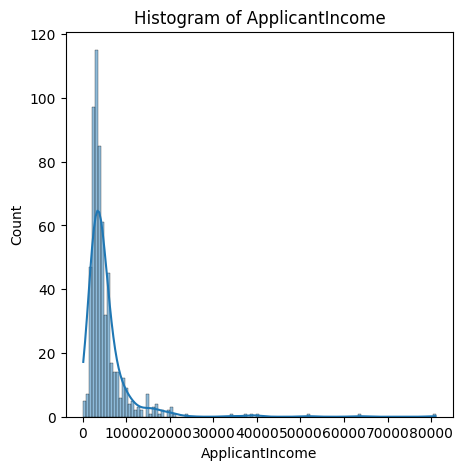

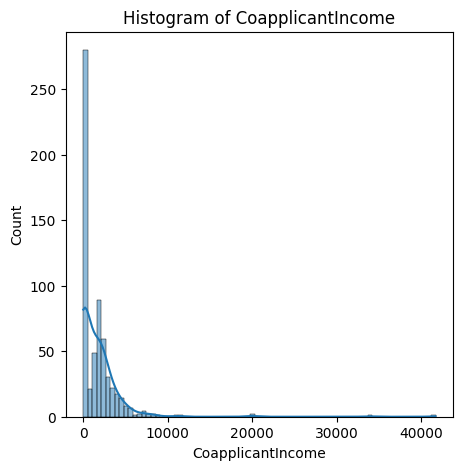

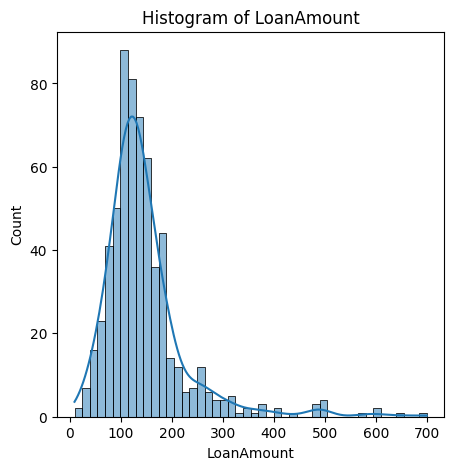

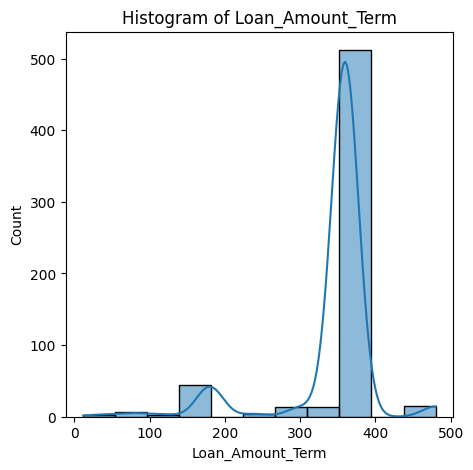

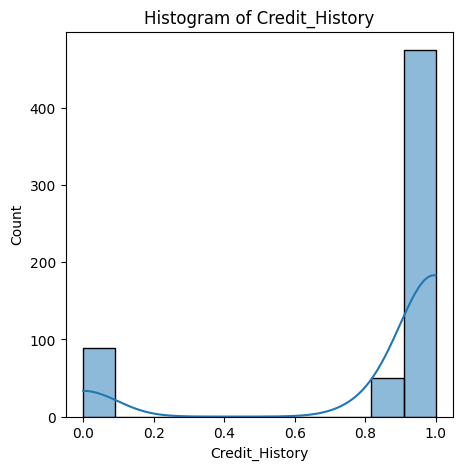

In [19]:
num_cols=df.select_dtypes(include=np.number).columns
for col in num_cols:
  plt.figure(figsize=(5,5))
  sns.histplot(df[col],kde=True)
  plt.title(f'Histogram of {col}')
  plt.show()

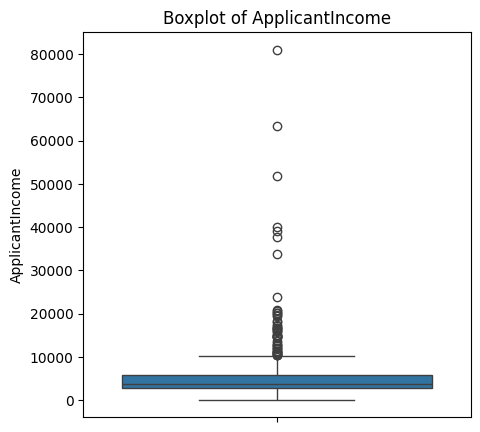

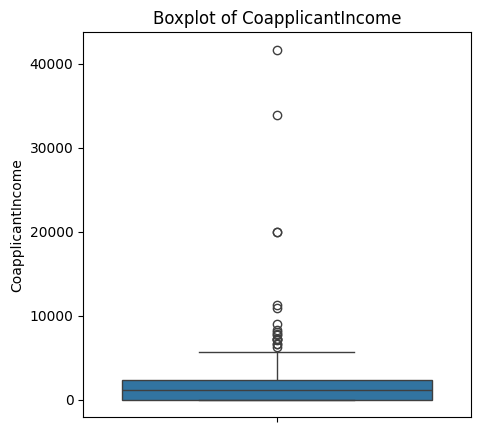

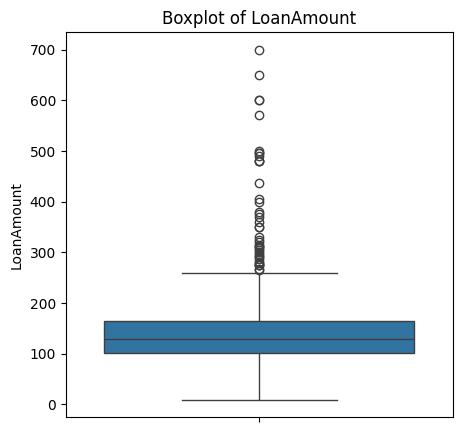

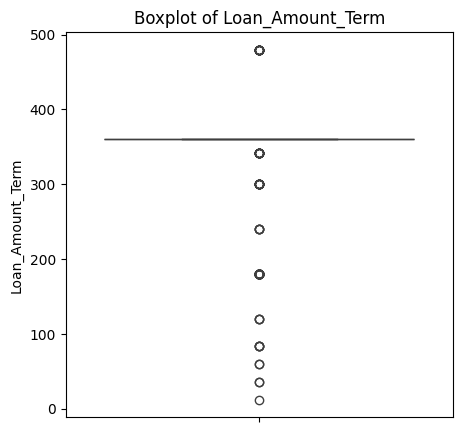

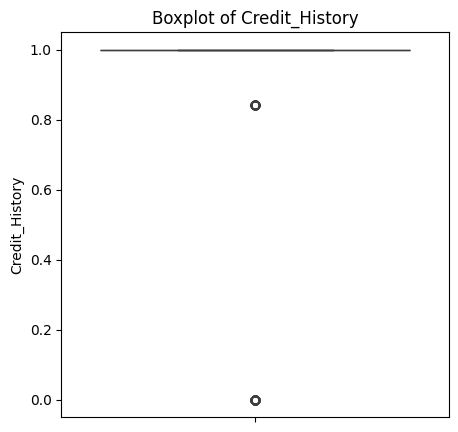

In [20]:
num_cols=df.select_dtypes(include=np.number).columns
for col in num_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(df[col])
  plt.title(f'Boxplot of {col}')
  plt.show()

In [21]:
df.dtypes

,0
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64


In [22]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y


In [23]:
#Label encoding
cols=['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in cols:
  df[col]=le.fit_transform(df[col])
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


In [40]:
#scaling
#Robust scaling
cols2=['ApplicantIncome','CoapplicantIncome','LoanAmount']
from sklearn.preprocessing import RobustScaler
robust=RobustScaler()
df[cols2]=robust.fit_transform(df[cols2])

In [25]:
df.corr(numeric_only=True)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Gender,1.000000,0.364569,0.172914,0.045364,-0.000525,0.058809,0.082912,0.107930,-0.073567,0.012819,-0.025752,0.017987
Married,0.364569,1.000000,0.334216,0.012304,0.004489,0.051708,0.075948,0.147141,-0.100863,0.005852,0.004257,0.091478
Dependents,0.172914,0.334216,1.000000,0.055752,0.056798,0.118202,0.030430,0.163106,-0.101054,-0.037392,-0.000244,0.010118
Education,0.045364,0.012304,0.055752,1.000000,-0.010383,-0.140760,-0.062290,-0.166998,-0.077242,-0.077936,-0.065243,-0.085884
Self_Employed,-0.000525,0.004489,0.056798,-0.010383,1.000000,0.127180,-0.016100,0.115260,-0.033943,-0.002260,-0.030860,-0.003700
ApplicantIncome,0.058809,0.051708,0.118202,-0.140760,0.127180,1.000000,-0.116605,0.565620,-0.045242,-0.014477,-0.009500,-0.004710
CoapplicantIncome,0.082912,0.075948,0.030430,-0.062290,-0.016100,-0.116605,1.000000,0.187828,-0.059675,-0.001665,0.010522,-0.059187
LoanAmount,0.107930,0.147141,0.163106,-0.166998,0.115260,0.565620,0.187828,1.000000,0.038801,-0.007738,-0.044776,-0.036416
Loan_Amount_Term,-0.073567,-0.100863,-0.101054,-0.077242,-0.033943,-0.045242,-0.059675,0.038801,1.000000,0.001395,-0.077620,-0.020974
Credit_History,0.012819,0.005852,-0.037392,-0.077936,-0.002260,-0.014477,-0.001665,-0.007738,0.001395,1.000000,-0.001880,0.540483


<Axes: >

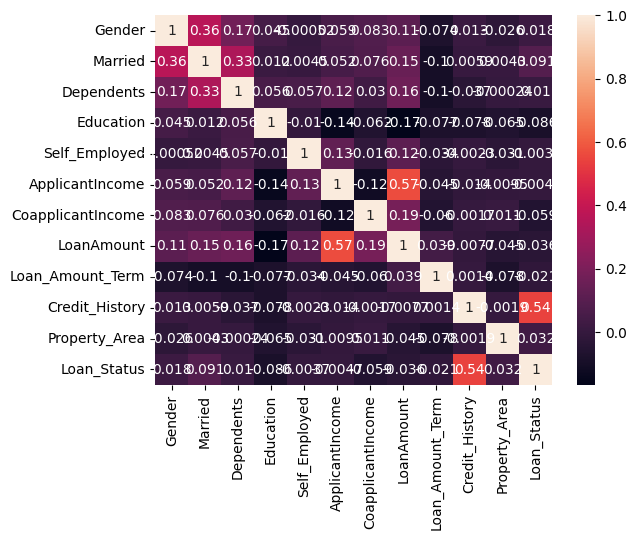

In [26]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [27]:
#Winsorize Method
cols1=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']
from scipy.stats.mstats import winsorize
for col in cols1:
    df[col] = winsorize(df[col], limits=(0, 0.1))
print("Outliers in column treated using winsorization method.")
df.head()

Outliers in column treated using winsorization method.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,0.698029,-0.517358,0.269956,360.0,1.0,2,1
1,1,1,1,0,0,0.264096,0.139079,-0.015504,360.0,1.0,0,0
2,1,1,0,0,1,-0.278492,-0.517358,-0.976744,360.0,1.0,2,1
3,1,1,0,1,0,-0.421422,0.509087,-0.139535,360.0,1.0,2,1
4,1,0,0,0,0,0.749786,-0.517358,0.186047,360.0,1.0,2,1


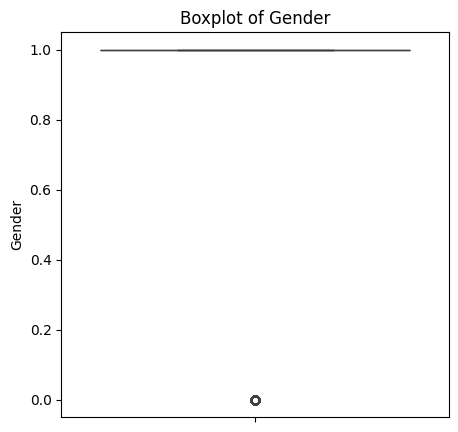

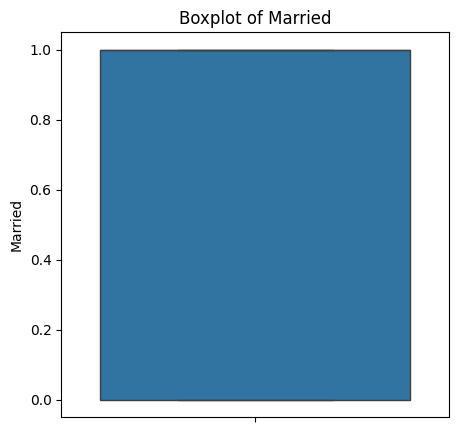

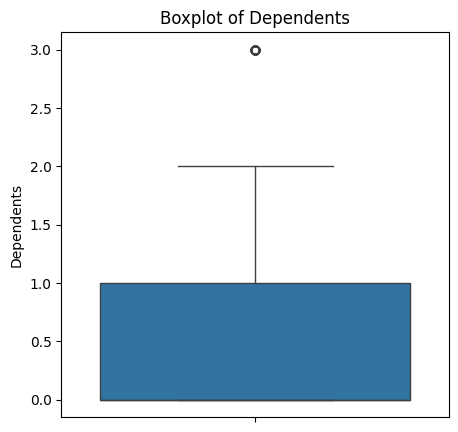

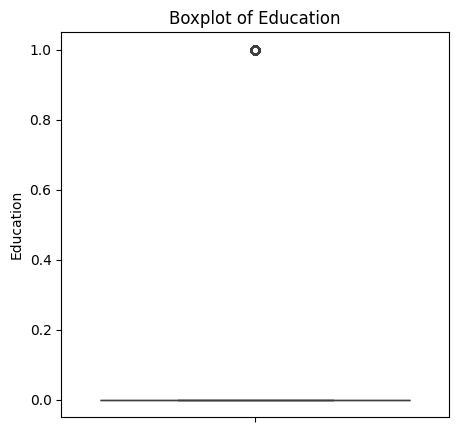

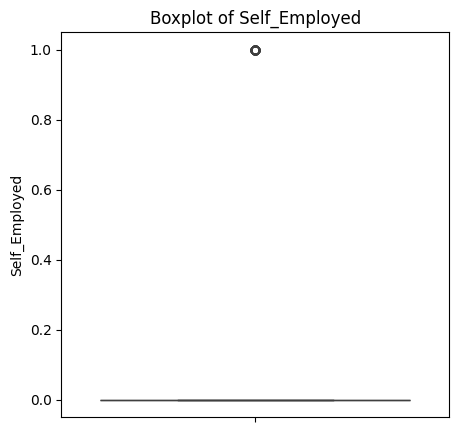

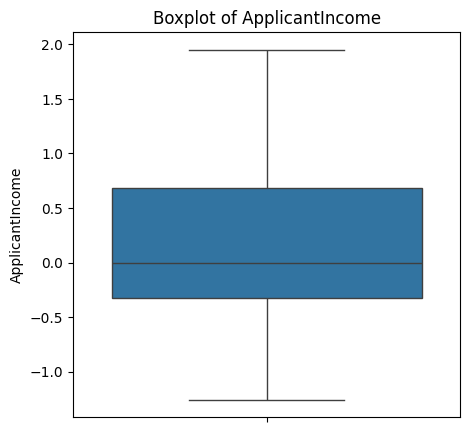

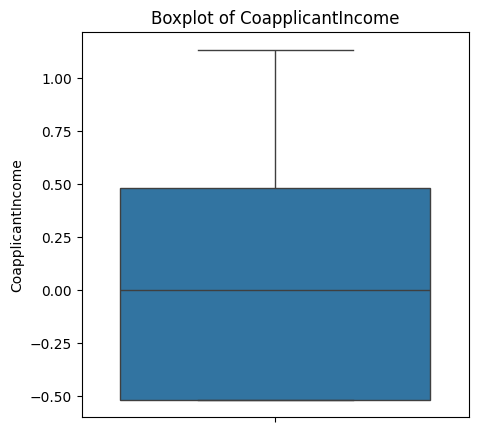

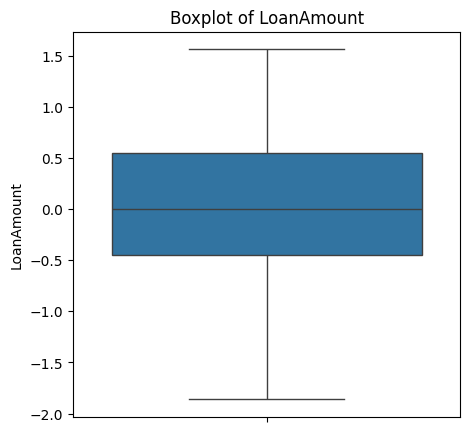

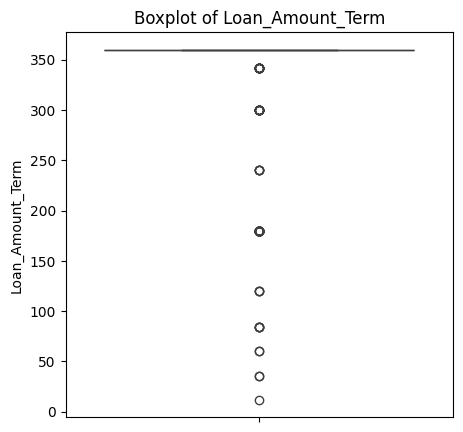

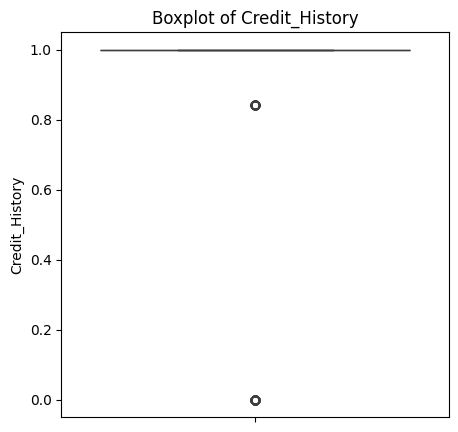

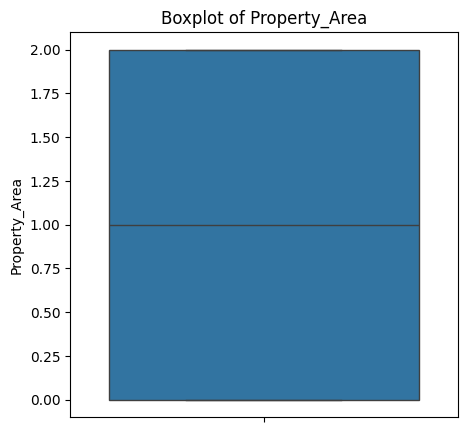

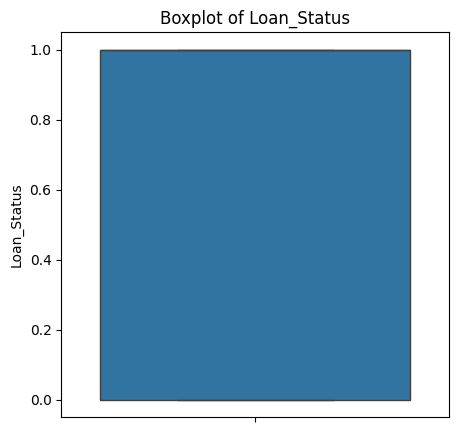

In [28]:
num_cols=df.select_dtypes(include=np.number).columns
for col in num_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(df[col])
  plt.title(f'Boxplot of {col}')
  plt.show()

In [29]:
X=df.drop(columns=['Loan_Status'])
y=df['Loan_Status']

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [31]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(random_state=42)
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy of LogisticRegression=",accuracy_score(y_test,y_pred))
print("confusion matrix of LogisticRegression =",confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy of LogisticRegression= 0.7967479674796748
confusion matrix of LogisticRegression = [[19 24]
 [ 1 79]]
              precision    recall  f1-score   support

           0       0.95      0.44      0.60        43
           1       0.77      0.99      0.86        80

    accuracy                           0.80       123
   macro avg       0.86      0.71      0.73       123
weighted avg       0.83      0.80      0.77       123



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(criterion='gini',max_depth=5,min_samples_split=10,random_state=42,min_samples_leaf=10)
dt_model.fit(X_train,y_train)
y_pred=dt_model.predict(X_test)
print(accuracy_score(y_test,y_pred))
confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred))

0.7479674796747967
              precision    recall  f1-score   support

           0       0.70      0.49      0.58        43
           1       0.76      0.89      0.82        80

    accuracy                           0.75       123
   macro avg       0.73      0.69      0.70       123
weighted avg       0.74      0.75      0.73       123



In [33]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=20,max_depth=10,min_samples_split=3)
rf_model.fit(X_train,y_train)
y_pred=rf_model.predict(X_test)
print(accuracy_score(y_test,y_pred))
confusion_matrix(y_test,y_pred)

0.7967479674796748


array([[19, 24],
       [ 1, 79]])

In [34]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=10)
knn_model.fit(X_train,y_train)
y_pred=knn_model.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.6910569105691057
[[10 33]
 [ 5 75]]
              precision    recall  f1-score   support

           0       0.67      0.23      0.34        43
           1       0.69      0.94      0.80        80

    accuracy                           0.69       123
   macro avg       0.68      0.59      0.57       123
weighted avg       0.68      0.69      0.64       123



In [45]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,0.698029,-0.517358,0.269956,360.0,1.0,2,1
1,1,1,1,0,0,0.264096,0.139079,-0.015504,360.0,1.0,0,0
2,1,1,0,0,1,-0.278492,-0.517358,-0.976744,360.0,1.0,2,1
3,1,1,0,1,0,-0.421422,0.509087,-0.139535,360.0,1.0,2,1
4,1,0,0,0,0,0.749786,-0.517358,0.186047,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,-0.312768,-0.517358,-0.899225,360.0,1.0,0,1
610,1,1,3,0,0,0.100600,-0.517358,-1.379845,180.0,1.0,0,1
611,1,1,1,0,0,1.459983,-0.412885,1.565891,360.0,1.0,2,1
612,1,1,2,0,0,1.292374,-0.517358,0.899225,360.0,1.0,2,1


In [50]:
new_data_raw = np.array(
    [[1,0,1,1,1,5000,1000,150,340,1,2],
    [0,1,0,0,0,2,5400,1500,160,300,0]])
new_data_df = pd.DataFrame(new_data_raw, columns=X.columns)

cols_to_scale = ['ApplicantIncome','CoapplicantIncome','LoanAmount']

new_data_df[cols_to_scale] = robust.transform(new_data_df[cols_to_scale])
new_data = new_data_df
new_data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,1,1,1,5000.0,1000.0,150.0,340,1,2
1,0,1,0,0,0,2.0,5400.0,1500.0,160,300,0


In [51]:
prediction = rf_model.predict(new_data)
prediction

array([1, 0])